# Equilibrium nucleotide calculations pipeline

---

## 1. Calculate rate and Bin

### 1a. For substitutions

In [3]:
import pandas as pd
import numpy as np

# Read the mutation counts file
mutation_file = "/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homologous Primate Genes All Alignment 60.0% Cutoff Primate SNP Human_mutation_count.txt"  # Replace with your actual file name
mutations_df = pd.read_csv(mutation_file, sep='\t')

# Read the nucleotide content file
content_file = "/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Ancestral_nucleotide_content_perposition_nonCpG.txt"  # Replace with your actual file name
content_df = pd.read_csv(content_file, sep='\t')

# Merge the dataframes on Position
merged_df = pd.merge(content_df, mutations_df, on='Position')

# Calculate mutation rates
merged_df['A to G per A'] = merged_df['A>G'] / merged_df['A']
merged_df['T to C per T'] = merged_df['T>C'] / merged_df['T']
merged_df['C to T per C'] = merged_df['C>T'] / merged_df['C (non-CpG)']
merged_df['G to A per G'] = merged_df['G>A'] / merged_df['G (non-CpG)']

merged_df['A to C per A'] = merged_df['A>C'] / merged_df['A']
merged_df['T to G per T'] = merged_df['T>G'] / merged_df['T']
merged_df['C to A per C'] = merged_df['C>A'] / merged_df['C']
merged_df['G to T per G'] = merged_df['G>T'] / merged_df['G']

merged_df['A to T per A'] = merged_df['A>T'] / merged_df['A']
merged_df['T to A per T'] = merged_df['T>A'] / merged_df['T']
merged_df['C to G per C'] = merged_df['C>G'] / merged_df['C']
merged_df['G to C per G'] = merged_df['G>C'] / merged_df['G']

# List of rate columns for transformation
rate_columns = [
    'A to G per A', 'T to C per T', 'C to T per C', 'G to A per G',
    'A to C per A', 'T to G per T', 'C to A per C', 'G to T per G',
    'A to T per A', 'T to A per T', 'C to G per C', 'G to C per G'
]

# Apply rate/(1-rate) transformation
for col in rate_columns:
    # Add a small epsilon to avoid division by zero if rate = 1
    merged_df[col] = merged_df[col] / (1 - merged_df[col] + 1e-10)

# Calculate bin numbers (40 positions per bin)
merged_df['Bin'] = ((merged_df['Position'] - 1) // 50) + 1

# List of content columns to bin (sum them within each bin)
content_columns = ['A', 'T', 'C', 'G']

# Group by bin and calculate:
# - Sum for content columns
# - Mean for rate columns (which are now transformed)
binned_df = merged_df.groupby('Bin').agg({
    **{col: 'sum' for col in content_columns},
    **{col: 'mean' for col in rate_columns}
}).reset_index()

# Rename Bin to Position for output
binned_df.rename(columns={'Bin': 'Position'}, inplace=True)

# Rename content columns to match desired output format
binned_df.rename(columns={
    'A': 'A Content',
    'T': 'T Content',
    'C': 'C Content',
    'G': 'G Content'
}, inplace=True)

# Reorder columns to match the desired format
output_columns = [
    'Position',
    'A Content', 'T Content', 'C Content', 'G Content',
    'A to G per A', 'T to C per T', 'C to T per C', 'G to A per G',
    'A to C per A', 'T to G per T', 'C to A per C', 'G to T per G',
    'A to T per A', 'T to A per T', 'C to G per C', 'G to C per G'
]

binned_df = binned_df[output_columns]

# Format all rate columns to show 9 decimal places
for col in rate_columns:
    binned_df[col] = binned_df[col].apply(lambda x: f'{x:.9f}')

# Save the binned data to a CSV file
binned_df.to_csv('Substitution_human_nonCpG_5kb_binned_50_new.csv', sep=',', index=False)

print("Mutation rates calculated, transformed (rate/(1-rate)), and binned into 40-position bins")
print(f"Binned data saved to 'Substitution_human_nonCpG_5kb_binned_40.csv'")
print(f"Number of bins: {len(binned_df)}")
print("\nFirst few rows of the binned output:")
print(binned_df.head().to_string())

# Optional: Display bin ranges for verification
print("\nBin ranges:")
for bin_num in range(1, min(6, len(binned_df) + 1)):
    start_pos = (bin_num - 1) * 50 + 1
    end_pos = bin_num * 50
    print(f"Bin {bin_num} (Position in output): covers nucleotide positions {start_pos}-{end_pos}")

# Optional: Also save a version with original rates (without transformation) if needed
# binned_df_original = binned_df.copy()
# binned_df_original.to_csv('Substitution_human_nonCpG_5kb_binned_40_original_rates.csv', sep=',', index=False)

Mutation rates calculated, transformed (rate/(1-rate)), and binned into 40-position bins
Binned data saved to 'Substitution_human_nonCpG_5kb_binned_40.csv'
Number of bins: 100

First few rows of the binned output:
   Position  A Content  T Content  C Content  G Content A to G per A T to C per T C to T per C G to A per G A to C per A T to G per T C to A per C G to T per G A to T per A T to A per T C to G per C G to C per G
0         1     115476     113711      96329      95700  0.002806608  0.003061145  0.003989077  0.003659348  0.000825579  0.000659942  0.001020904  0.001067048  0.000598761  0.000748557  0.001111350  0.001226828
1         2     115007     114441      96151      96881  0.003060784  0.003125772  0.004104051  0.003389748  0.000732564  0.000760878  0.000989637  0.000918678  0.000610700  0.000728058  0.001095421  0.001186510
2         3     115120     114566      97380      96512  0.002596379  0.002979269  0.003803180  0.003434931  0.000773836  0.000638160  0.001213233  0.

### 1b. For RareSNPs

In [8]:
import pandas as pd
import numpy as np

# Read the mutation counts file
mutation_file = "/home/alexpalazzo1/Documents/Tina/Rare_SNP/rareSNP_mapped_TSS_5kb_nucleotide_surround_nonCpG_count.csv"
mutations_df = pd.read_csv(mutation_file, sep=',')

# Read the nucleotide content file (new format)
content_file = "/home/alexpalazzo1/Documents/Tina/Rare_SNP/Fantom5_CAGE_hg38_gencode.v40_TSS_5kb_per_position_CpG.txt"  # Update with your actual file name
content_df = pd.read_csv(content_file, sep='\t')

# Merge the dataframes on Position
merged_df = pd.merge(content_df, mutations_df, on='Position')

# Calculate mutation rates
merged_df['A to G per A'] = merged_df['A>G'] / merged_df['A Content']
merged_df['T to C per T'] = merged_df['T>C'] / merged_df['T Content']
merged_df['C to T per C'] = merged_df['C>T'] / merged_df['C_not_in_CpG']
merged_df['G to A per G'] = merged_df['G>A'] / merged_df['G_not_in_CpG']

merged_df['A to C per A'] = merged_df['A>C'] / merged_df['A Content']
merged_df['T to G per T'] = merged_df['T>G'] / merged_df['T Content']
merged_df['C to A per C'] = merged_df['C>A'] / merged_df['C Content']
merged_df['G to T per G'] = merged_df['G>T'] / merged_df['G Content']

merged_df['A to T per A'] = merged_df['A>T'] / merged_df['A Content']
merged_df['T to A per T'] = merged_df['T>A'] / merged_df['T Content']
merged_df['C to G per C'] = merged_df['C>G'] / merged_df['C Content']
merged_df['G to C per G'] = merged_df['G>C'] / merged_df['G Content']

# List of rate columns for transformation
rate_columns = [
    'A to G per A', 'T to C per T', 'C to T per C', 'G to A per G',
    'A to C per A', 'T to G per T', 'C to A per C', 'G to T per G',
    'A to T per A', 'T to A per T', 'C to G per C', 'G to C per G'
]

# Apply rate/(1-rate) transformation
for col in rate_columns:
    # Add a small epsilon to avoid division by zero if rate = 1
    merged_df[col] = merged_df[col] / (1 - merged_df[col] + 1e-10)

# Calculate bin numbers (40 positions per bin)
merged_df['Bin'] = ((merged_df['Position'] - 1) // 50) + 1

# List of content columns to bin (sum them within each bin)
content_columns = ['A Content', 'T Content', 
                   'C Content', 'G Content']

# Group by bin and calculate:
# - Sum for content columns
# - Mean for rate columns (which are now transformed)
binned_df = merged_df.groupby('Bin').agg({
    **{col: 'sum' for col in content_columns},
    **{col: 'mean' for col in rate_columns}
}).reset_index()

# Rename Bin to Position for output
binned_df.rename(columns={'Bin': 'Position'}, inplace=True)

# Reorder columns to match the desired format
output_columns = [
    'Position',
    'A Content', 'T Content', 'C Content', 'G Content',
    'A to G per A', 'T to C per T', 'C to T per C', 'G to A per G',
    'A to C per A', 'T to G per T', 'C to A per C', 'G to T per G',
    'A to T per A', 'T to A per T', 'C to G per C', 'G to C per G'
]

binned_df = binned_df[output_columns]

# Format all rate columns to show 9 decimal places
for col in rate_columns:
    binned_df[col] = binned_df[col].apply(lambda x: f'{x:.9f}')

# Save the binned data to a CSV file
binned_df.to_csv('RareSNP_human_nonCpG_5kb_binned_50_new.csv', sep=',', index=False)

print("Mutation rates calculated, transformed (rate/(1-rate)), and binned into 40-position bins")
print(f"Binned data saved to 'Substitution_human_nonCpG_5kb_binned_40.csv'")
print(f"Number of bins: {len(binned_df)}")
print("\nFirst few rows of the binned output:")
print(binned_df.head().to_string())

# Print column information to verify we're using the right columns
print("\nColumns used from content file:")
print(f"- A Content: column 2")
print(f"- T Content: column 3")  
print(f"- C Content (not in CpG): column 8")
print(f"- G Content (not in CpG): column 9")

# Optional: Display bin ranges for verification
print("\nBin ranges:")
for bin_num in range(1, min(6, len(binned_df) + 1)):
    start_pos = (bin_num - 1) * 50 + 1
    end_pos = bin_num * 50
    print(f"Bin {bin_num} (Position in output): covers nucleotide positions {start_pos}-{end_pos}")

Mutation rates calculated, transformed (rate/(1-rate)), and binned into 40-position bins
Binned data saved to 'Substitution_human_nonCpG_5kb_binned_40.csv'
Number of bins: 100

First few rows of the binned output:
   Position  A Content  T Content  C Content  G Content A to G per A T to C per T C to T per C G to A per G A to C per A T to G per T C to A per C G to T per G A to T per A T to A per T C to G per C G to C per G
0         1     235261     234502     193758     191779  0.083921028  0.092519826  0.127557089  0.125737007  0.025105004  0.024970853  0.043981159  0.040889165  0.020558945  0.021462894  0.045500915  0.047630061
1         2     233936     234690     193673     193001  0.082747403  0.093421700  0.129061442  0.126004141  0.025262524  0.025205274  0.043254773  0.041725307  0.020689853  0.021143208  0.045503167  0.047501222
2         3     233868     234972     193947     192513  0.082468407  0.093468209  0.127875560  0.127810477  0.025458056  0.024281772  0.043745484  0.

---
## 2. Calculate equilibrium nucleotide content given mutation rates

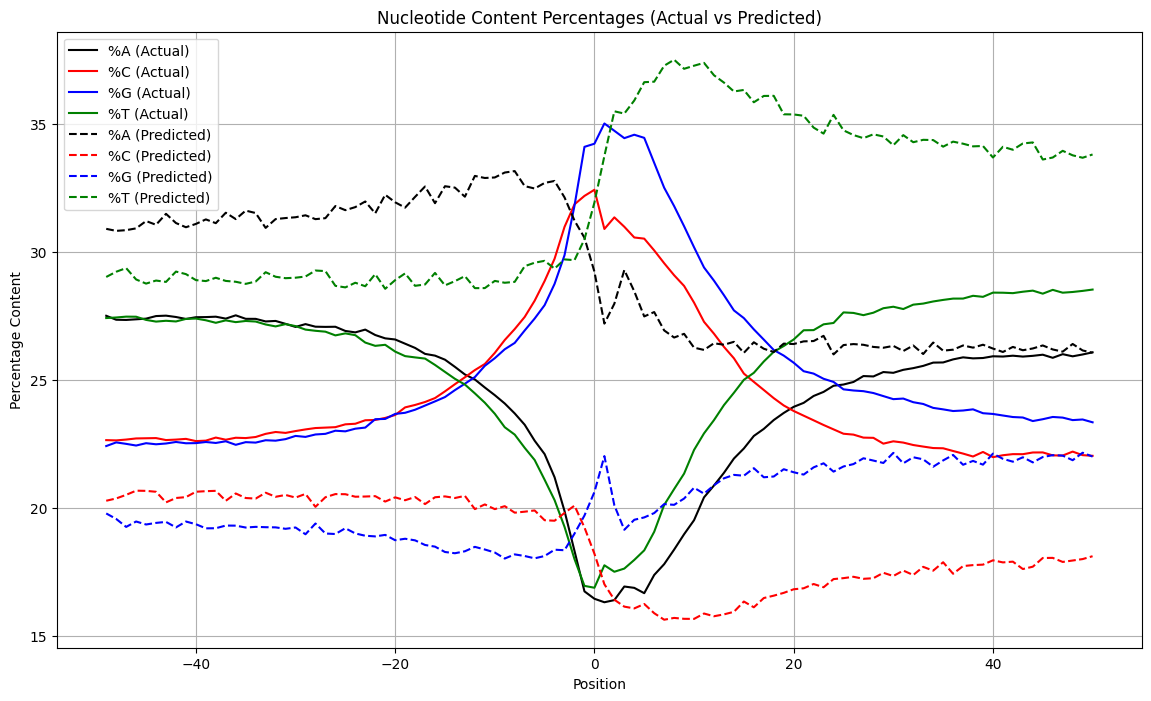

Equilibrium nucleotide content has been saved to RareSNP_human_nonCpG_5kb_equilibrium_nucleotide_content_50_new.csv


In [9]:
import csv
import matplotlib.pyplot as plt
import numpy as np

# Define the path to your CSV mutation rate file
import os
os.chdir("/home/alexpalazzo1/Documents/Tina/Rare_SNP/Equilibrium")

def Nuc_Eq(QAG, QAC, QAT, QCT, QCA, QCG, QGA, QGT, QGC, QTC, QTG, QTA):
    QAA = -(QAG+QAC+QAT)
    QCC = -(QCT+QCA+QCG)
    QGG = -(QGA+QGT+QGC)
    QTT = -(QTC+QTG+QTA)
    # Rate matrix Q
    Q = np.array([
        [QAA, QAC, QAG, QAT],
        [QCA, QCC, QCG, QCT],
        [QGA, QGC, QGG, QGT],
        [QTA, QTC, QTG, QTT]
    ])

    # Adding the normalization condition (sum to 1)
    Q = np.vstack([Q.T, np.ones(Q.shape[0])])
    b = np.zeros(Q.shape[0])
    b[-1] = 1

    # Solve the linear system
    pi = np.linalg.lstsq(Q, b, rcond=None)[0]
    return pi

# Initialize lists to store the actual and predicted percentages for each nucleotide
position = []
actual_A = []
actual_C = []
actual_G = []
actual_T = []
predicted_A = []
predicted_C = []
predicted_G = []
predicted_T = []

# Output file for equilibrium nucleotide content
output_file = "RareSNP_human_nonCpG_5kb_equilibrium_nucleotide_content_50_new.csv"

# Read the CSV mutation rate file and write output
with open("RareSNP_human_nonCpG_5kb_binned_50_new.csv", mode='r') as file, \
     open(output_file, mode='w', newline='') as out_file:
    
    reader = csv.reader(file)
    writer = csv.writer(out_file)
    
    # Write header for output file
    writer.writerow(['Position', 'Actual_A%', 'Actual_C%', 'Actual_G%', 'Actual_T%',
                    'Predicted_A%', 'Predicted_C%', 'Predicted_G%', 'Predicted_T%'])
    
    header = next(reader)  # Read the header from input file
    
    # Process each subsequent line in the CSV
    for line_number, line in enumerate(reader, start=1):
        if 1 <= line_number <= 1000:
            try:
                # Extract nucleotide contents and mutation rates from each line
                A_content = float(line[1])
                T_content = float(line[2])
                C_content = float(line[3])
                G_content = float(line[4])
                
                QAG = float(line[5])
                QTC = float(line[6])
                QCT = float(line[7])
                QGA = float(line[8])
                QAC = float(line[9])
                QTG = float(line[10])
                QCA = float(line[11])
                QGT = float(line[12])
                QAT = float(line[13])
                QTA = float(line[14])
                QCG = float(line[15])
                QGC = float(line[16])
                
                # Calculate total content
                total_content = A_content + T_content + C_content + G_content
                
                # Calculate percentages for each nucleotide
                percent_A = (A_content / total_content) * 100
                percent_C = (C_content / total_content) * 100
                percent_G = (G_content / total_content) * 100
                percent_T = (T_content / total_content) * 100

                # Calculate equilibrium nucleotide content
                pi = Nuc_Eq(QAG, QAC, QAT, QCT, QCA, QCG, QGA, QGT, QGC, QTC, QTG, QTA)
                pA = pi[0] * 100
                pC = pi[1] * 100
                pG = pi[2] * 100
                pT = pi[3] * 100

                # Store the actual percentages and predicted percentages
                current_position = line_number - 50
                position.append(current_position)
                actual_A.append(percent_A)
                actual_C.append(percent_C)
                actual_G.append(percent_G)
                actual_T.append(percent_T)
                predicted_A.append(pA)
                predicted_C.append(pC)
                predicted_G.append(pG)
                predicted_T.append(pT)
                
                # Write to output file
                writer.writerow([current_position, percent_A, percent_C, percent_G, percent_T,
                               pA, pC, pG, pT])
            except Exception as e:
                print(f"Error processing line {line_number}: {e}")
                continue

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_A, 'k-', label='%A (Actual)')
plt.plot(position, actual_C, 'r-', label='%C (Actual)')
plt.plot(position, actual_G, 'b-', label='%G (Actual)')
plt.plot(position, actual_T, 'g-', label='%T (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_A, 'k--', label='%A (Predicted)')
plt.plot(position, predicted_C, 'r--', label='%C (Predicted)')
plt.plot(position, predicted_G, 'b--', label='%G (Predicted)')
plt.plot(position, predicted_T, 'g--', label='%T (Predicted)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Equilibrium nucleotide content has been saved to {output_file}")

---
## 3. Plot nucleotide content separately

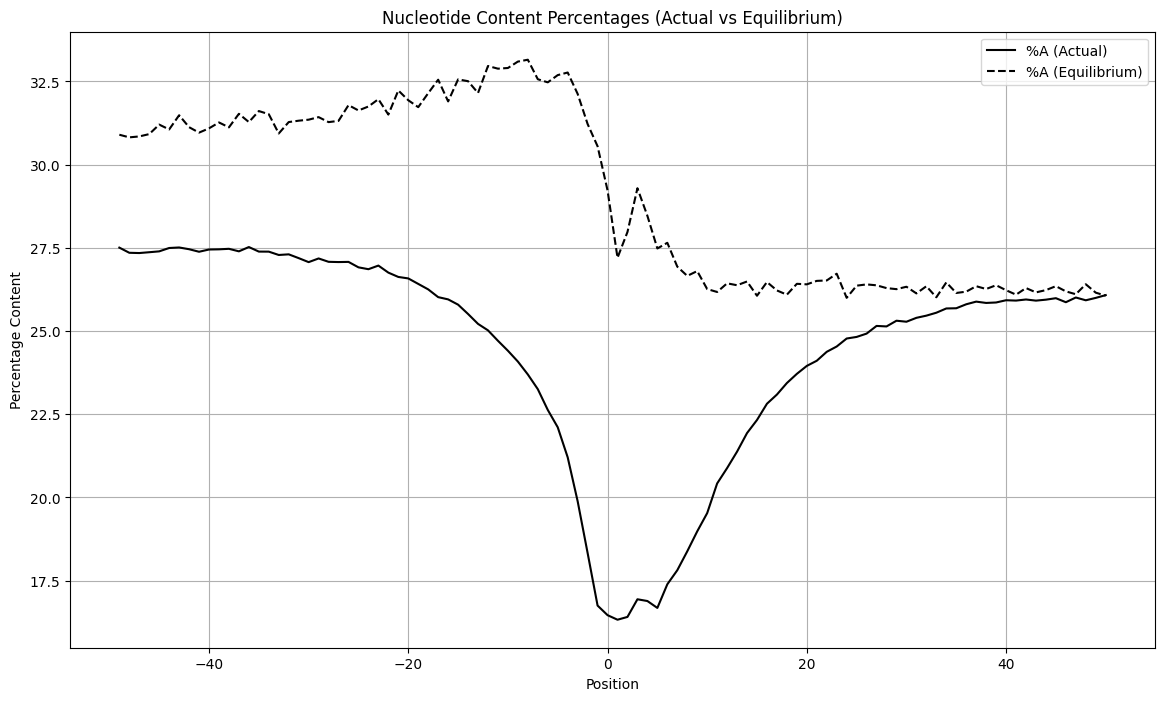

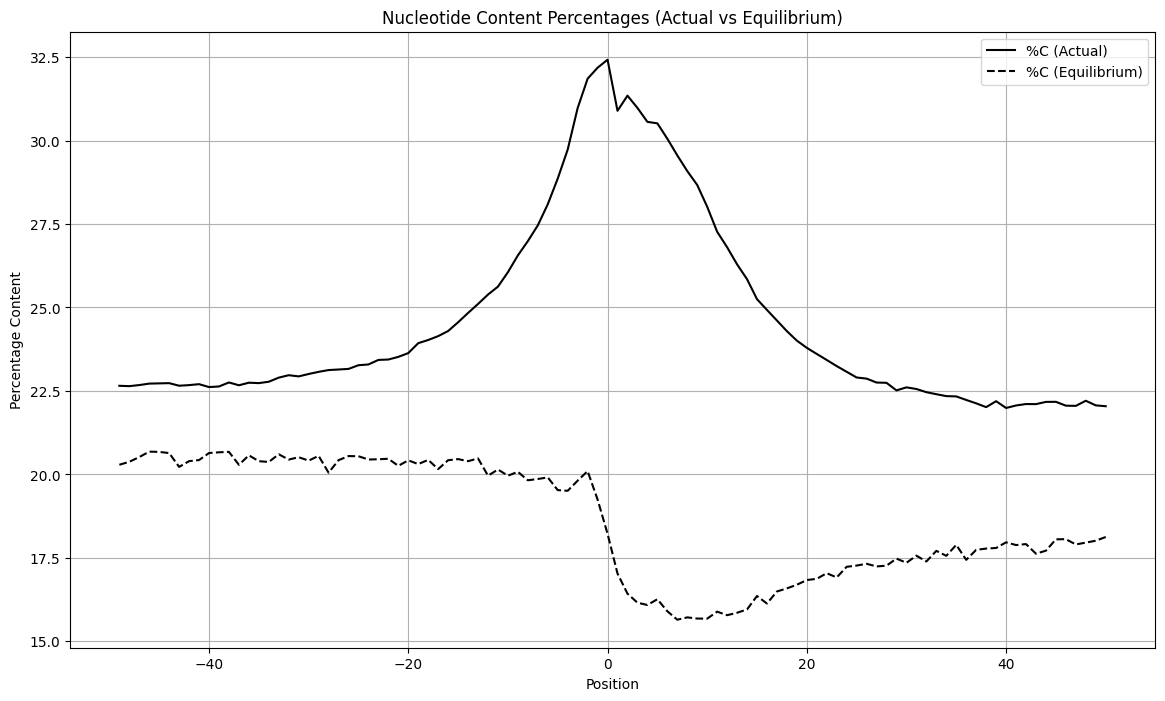

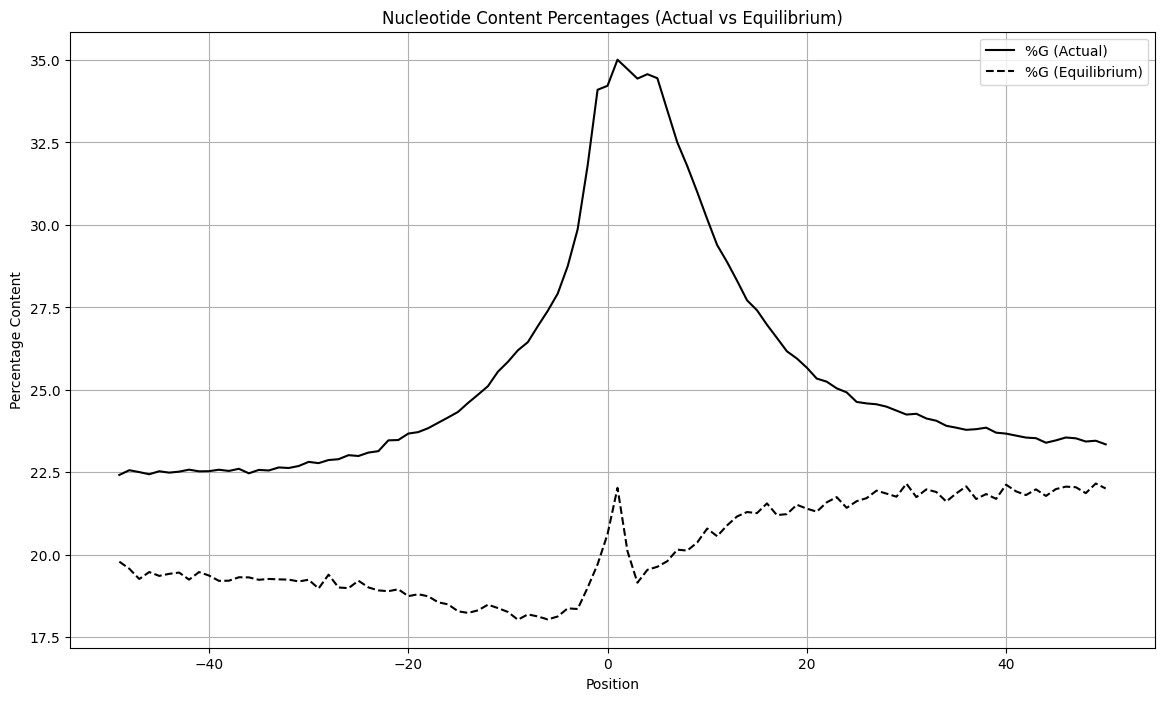

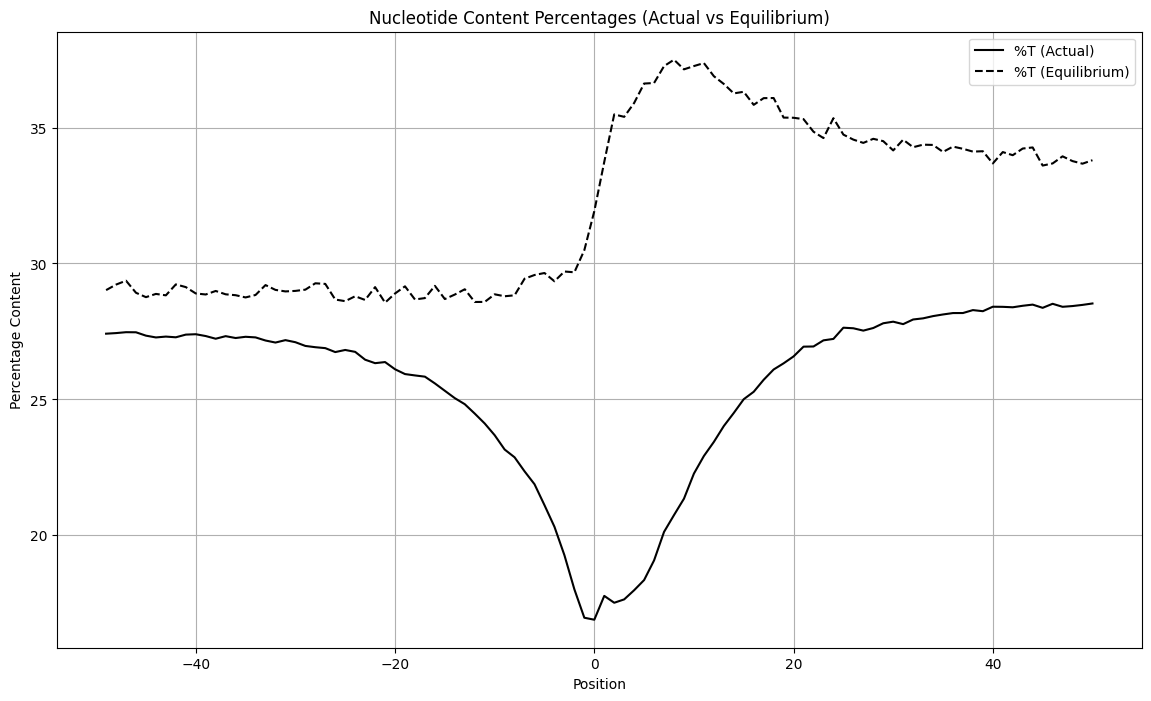

In [10]:
# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_A, 'k-', label='%A (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_A, 'k--', label='%A (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('A')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_C, 'k-', label='%C (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_C, 'k--', label='%C (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('C')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_G, 'k-', label='%G (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_G, 'k--', label='%G (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('G')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_T, 'k-', label='%T (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_T, 'k--', label='%T (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('T')
plt.show()
